In [28]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.figsize": (14, 12),
})


In [38]:
def ctts_cost(
    *,
    P,
    L,
    D,
    r,
    Lin,
    Lout,
    N,
    Igpu,
    Icomm,
    K,
    bytes_per_param=2
):
    P_layer = P / L
    bP_layer = bytes_per_param * P_layer

    linear_compute = 2 * N * P * Lout

    attention_compute = (
        2 * r * N * Lin * D * Lout +
        r * N * D * (Lout ** 2)
    )

    memory_cost = Igpu * (
        2 * P * Lout +
        2 * Lin * D * Lout +
        N * D * (Lout ** 2)
    )

    offload_cost = Icomm * (
        bP_layer * K * (Lin + N * Lout)
    )

    return linear_compute + attention_compute + memory_cost + offload_cost


In [39]:
def cost_additive(**kwargs):
    return ctts_cost(**kwargs)

def cost_max(**kwargs):
    P, Lout, N = kwargs["P"], kwargs["Lout"], kwargs["N"]
    Lin, D, r = kwargs["Lin"], kwargs["D"], kwargs["r"]
    Igpu, Icomm, K = kwargs["Igpu"], kwargs["Icomm"], kwargs["K"]
    L = kwargs["L"]
    bytes_per_param = kwargs.get("bytes_per_param", 2)

    P_layer = P / L
    bP_layer = bytes_per_param * P_layer

    compute = (
        2 * N * P * Lout +
        2 * r * N * Lin * D * Lout +
        r * N * D * (Lout ** 2)
    )

    memory = Igpu * (
        2 * P * Lout +
        2 * Lin * D * Lout +
        N * D * (Lout ** 2)
    )

    comm = Icomm * (
        bP_layer * K * (Lin + N * Lout)
    )

    return max(compute + memory, comm)

def cost_kinetics(**kwargs):
    kwargs = dict(kwargs)
    kwargs["K"] = 0
    return ctts_cost(**kwargs)


In [40]:
results = {
    "Qwen-3-1.7B": {
        "P": 2.0e9,
        "L": 28,
        "r": 2,
        "acc": {
            2048: 0.10, 4096: 0.27, 6144: 0.27, 8192: 0.30,
            10240: 0.30, 12288: 0.30, 14336: 0.30,
            16384: 0.33, 18432: 0.33, 20480: 0.33,
            22528: 0.33, 24576: 0.33,
            28768: 0.33, 30768: 0.33, 32768: 0.33,
        }
    },
    "Qwen-3-4B": {
        "P": 4.0e9,
        "L": 36,
        "r": 4,
        "acc": {
            2048: 0.033, 4096: 0.200, 6144: 0.333, 8192: 0.367,
            10240: 0.433, 12288: 0.500, 14336: 0.533,
            16384: 0.533, 18432: 0.567, 20480: 0.567,
            22528: 0.600, 24576: 0.600,
            28296: 0.600, 32296: 0.600,
        }
    },
    "Qwen-3-8B": {
        "P": 8.2e9,
        "L": 36,
        "r": 4,
        "acc": {
            2048: 0.1333, 4096: 0.2000, 6144: 0.3333,
            8192: 0.4000, 10240: 0.4000, 12288: 0.4667,
            14336: 0.5000, 16384: 0.5667,
            18432: 0.5667, 20480: 0.5667,
            22528: 0.5667, 24576: 0.6000,
            28768: 0.6333, 30768: 0.6333, 32768: 0.6333,
        }
    },
    "Qwen-3-14B": {
        "P": 14.8e9,
        "L": 40,
        "r": 5,
        "acc": {
            2048: 0.0667, 4096: 0.1667, 6144: 0.3333,
            8192: 0.5000, 10240: 0.6000, 12288: 0.6000,
            14336: 0.6333, 16384: 0.6333,
            18432: 0.6333, 20480: 0.6333,
            22528: 0.6333, 24576: 0.6333,
            28768: 0.6333, 30768: 0.6333, 32768: 0.6333,
        }
    },
}


In [41]:
Lin = 512
N = 1

# KV dimension (K + V)
D = 128 * 8 * 2

Igpu = 36.16
Icomm = 881.6

# Finer near zero
K_fracs = [
    0.0,
    0.01, 0.02, 0.05, 0.10,
    0.20, 0.35, 0.50, 0.75, 1.0
]


In [42]:
def is_feasible(Lout, K_frac):
    MAX_LEN_NO_OFFLOAD = 8192
    if K_frac == 0.0 and Lout > MAX_LEN_NO_OFFLOAD:
        return False
    return True


In [43]:
def build_grid(model, cost_fn):
    P, L, r = model["P"], model["L"], model["r"]
    grid = []

    for frac in K_fracs:
        K = max(1, int(frac * L)) if frac > 0 else 0

        for Lout, acc in model["acc"].items():
            if not is_feasible(Lout, frac):
                continue

            cost = cost_fn(
                P=P, L=L, D=D, r=r,
                Lin=Lin, Lout=Lout,
                N=N, Igpu=Igpu, Icomm=Icomm,
                K=K
            )

            grid.append({
                "cost": cost / 1e12,
                "acc": acc,
                "Lout": Lout,
                "K_frac": frac
            })

    return grid


In [44]:
def pareto_frontier(grid):
    grid = sorted(grid, key=lambda x: x["cost"])
    frontier = []
    best_acc = -1

    for g in grid:
        if g["acc"] > best_acc:
            frontier.append(g)
            best_acc = g["acc"]

    return frontier


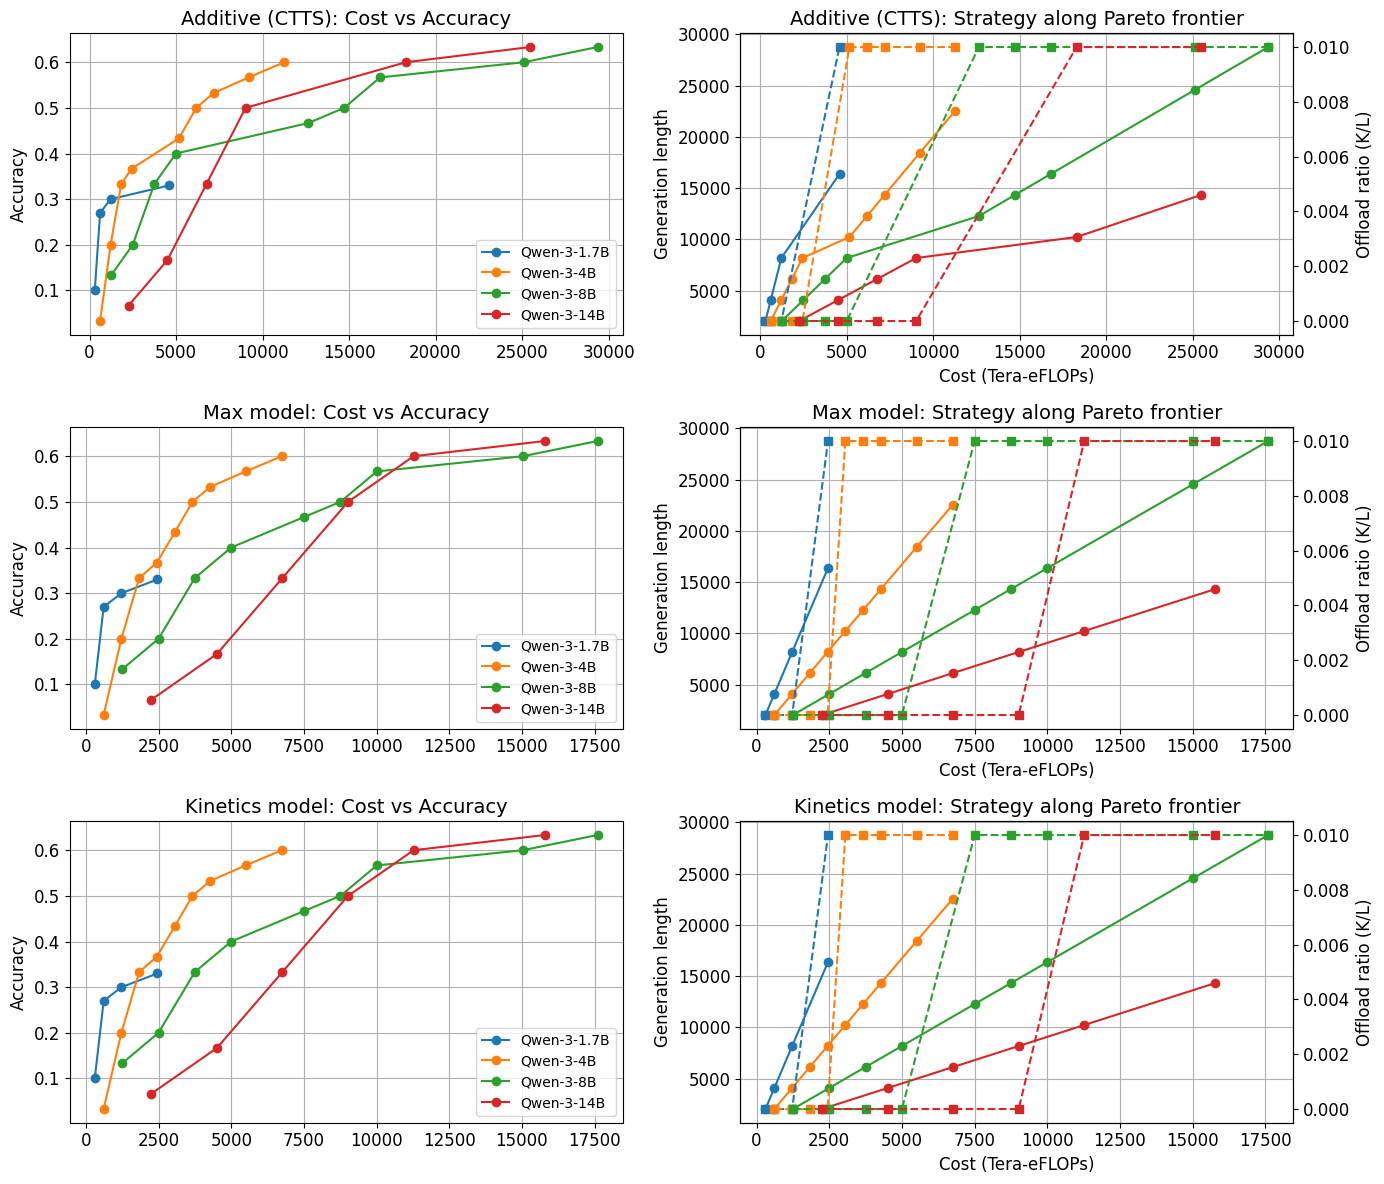

In [45]:
model_colors = {
    "Qwen-3-1.7B": "tab:blue",
    "Qwen-3-4B": "tab:orange",
    "Qwen-3-8B": "tab:green",
    "Qwen-3-14B": "tab:red",
}

cost_models = [
    ("Additive (CTTS)", cost_additive),
    ("Max model", cost_max),
    ("Kinetics model", cost_kinetics),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for row, (cost_label, cost_fn) in enumerate(cost_models):

    ax_acc = axes[row, 0]
    ax_strat = axes[row, 1]
    ax_len = ax_strat
    ax_off = ax_strat.twinx()

    for model_name, model in results.items():
        grid = build_grid(model, cost_fn)
        frontier = pareto_frontier(grid)

        costs = [p["cost"] for p in frontier]
        accs = [p["acc"] for p in frontier]
        lens = [p["Lout"] for p in frontier]
        offs = [p["K_frac"] for p in frontier]

        color = model_colors[model_name]

        ax_acc.plot(costs, accs, marker="o", color=color, label=model_name)
        ax_len.plot(costs, lens, marker="o", color=color)
        ax_off.plot(costs, offs, marker="s", linestyle="--", color=color)

    ax_acc.set_title(f"{cost_label}: Cost vs Accuracy")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.grid(True)
    ax_acc.legend()

    ax_len.set_title(f"{cost_label}: Strategy along Pareto frontier")
    ax_len.set_xlabel("Cost (Tera-eFLOPs)")
    ax_len.set_ylabel("Generation length")
    ax_len.grid(True)

    ax_off.set_ylabel("Offload ratio (K/L)")

plt.tight_layout()
plt.show()
